# Stage 2: NLOS Signal Quality Classifier (BERT)
## Multi-Model Pipeline — Correctable vs Challenging

**Purpose**: Given an NLOS signal (classified by Stage 1), classify its **signal quality** — is it correctable with straightforward bounce distance prediction, or does it present challenges for Stage 3?

**Two independent measurements from geometric ground truth (`bounce_path_idx`):**

| Measurement | What it checks |
|-------------|---------------|
| **Bounce dominance** | What fraction of CIR energy is concentrated at the known geometric bounce position? |
| **Peak count** | How many prominent peaks exist in the CIR region of interest? |

**Label (mixture rule):**
- **Correctable** (label=0): bounce dominance ≥ 50% AND num_peaks ≤ 2 — signal is clean and dominated by the expected bounce path
- **Challenging** (label=1): either low bounce dominance OR many peaks — multipath contamination makes correction harder

**Why this is NOT circular**: Labels come from geometric ground truth (floor plan → `bounce_path_idx`) and signal morphology (peak count). Features are 64-dim BERT embeddings (learned self-attention representations). These are independent.

**Architecture**: Frozen BERT_Classifier encoder → 64-dim Transformer embeddings → Random Forest Classifier

**Pipeline**: Stage 1 (BERT → LOS/NLOS) → **Stage 2 (BERT embeddings → RF → signal quality)** → Stage 3 (→ d_bounce prediction)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
import joblib
import re
import os

# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    # ROI alignment (same as Stage 1)
    "search_start": 740,
    "search_end": 810,
    # Peak detection — morphological CIR quality
    "peak_prominence": 0.20,
    "peak_min_distance": 5,
    "dominant_path_max_peaks": 2,
    # Geometric bounce dominance (amplitude ratio)
    "bounce_search_window": 3,
    "dominance_threshold": 0.50,
    # Random Forest
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    # Split
    "test_ratio": 0.30,
    "seed": 42,
}

np.random.seed(CONFIG["seed"])
print(f"Config: {CONFIG}")
print(f"\nLabel strategy: MIXTURE (geometric + morphological)")
print(f"  Criterion 1: bounce dominance (amplitude ratio) >= {CONFIG['dominance_threshold']:.0%}")
print(f"  Criterion 2: num_peaks <= {CONFIG['dominant_path_max_peaks']}")
print(f"  Correctable (0): BOTH conditions met")
print(f"  Challenging (1): either condition violated")
print(f"  Model input:   64-dim BERT embeddings → RF classifier")

Config: {'search_start': 740, 'search_end': 810, 'peak_prominence': 0.2, 'peak_min_distance': 5, 'dominant_path_max_peaks': 2, 'bounce_search_window': 3, 'dominance_threshold': 0.5, 'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'test_ratio': 0.3, 'seed': 42}

Label strategy: MIXTURE (geometric + morphological)
  Criterion 1: bounce dominance (amplitude ratio) >= 50%
  Criterion 2: num_peaks <= 2
  Correctable (0): BOTH conditions met
  Challenging (1): either condition violated
  Model input:   64-dim BERT embeddings → RF classifier


---
## Section 2: Data Loading & Mixture Quality Labeling

1. Load NLOS samples from the combined dataset
2. **Mixture labeling** from geometric ground truth + signal morphology:
   - **Bounce dominance**: fraction of CIR energy at the known `bounce_path_idx` (from TX→reflector→RX floor plan geometry)
   - **Peak count**: number of prominent peaks in the CIR ROI
   - Correctable = bounce dominance ≥ 50% AND num_peaks ≤ 2
   - Challenging = otherwise

**Note**: All NLOS data is single-bounce by geometry (TX → wall → RX). The two measurements capture different aspects of signal quality — geometric (energy concentration) and morphological (multipath complexity).

In [2]:
# ==========================================
# ROI ALIGNMENT (reused from Stage 1)
# ==========================================
def get_roi_alignment(sig, search_start=CONFIG["search_start"],
                      search_end=CONFIG["search_end"]):
    """Find leading edge by backtracking from peak."""
    region = sig[search_start:search_end]
    if len(region) == 0:
        return np.argmax(sig)

    peak_local = np.argmax(region)
    peak_idx = search_start + peak_local
    peak_val = sig[peak_idx]

    noise_section = sig[:search_start]
    if len(noise_section) > 10:
        noise_mean = np.mean(noise_section)
        noise_std = np.std(noise_section)
        threshold = max(noise_mean + 3 * noise_std, 0.05 * peak_val)
    else:
        threshold = 0.05 * peak_val

    leading_edge = peak_idx
    for i in range(peak_idx, max(search_start - 20, 0), -1):
        if sig[i] < threshold:
            leading_edge = i + 1
            break

    return leading_edge


# ==========================================
# COUNT PEAKS IN CIR ROI
# ==========================================
def count_peaks_in_roi(sig, leading_edge, config=CONFIG):
    """Count prominent peaks in CIR ROI (120 samples from leading edge)."""
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]
    if len(roi) == 0 or np.max(roi) == 0:
        return 0
    roi_norm = roi / np.max(roi)
    peaks, _ = find_peaks(
        roi_norm,
        prominence=config["peak_prominence"],
        distance=config["peak_min_distance"]
    )
    return len(peaks)


# ==========================================
# GEOMETRIC BOUNCE DOMINANCE (AMPLITUDE RATIO)
# ==========================================
def compute_bounce_dominance(sig, leading_edge, bounce_path_idx,
                              window=CONFIG["bounce_search_window"]):
    """
    Amplitude ratio: peak amplitude near bounce position / strongest peak in ROI.
    Returns 0-1. High value = bounce peak is the dominant peak.
    """
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]

    if len(roi) == 0 or np.max(roi) == 0:
        return 0.0

    strongest_amp = float(np.max(roi))

    bounce_idx = int(round(bounce_path_idx))
    b_start = max(0, bounce_idx - window)
    b_end = min(len(sig), bounce_idx + window + 1)

    if b_start >= b_end:
        return 0.0

    bounce_amp = float(np.max(sig[b_start:b_end]))
    return bounce_amp / strongest_amp


# ==========================================
# STRONGEST PEAK POWER IN ROI
# ==========================================
def get_strongest_peak_power(sig, leading_edge):
    """Max CIR amplitude in ROI after RXPACC normalization."""
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]
    if len(roi) == 0:
        return 0.0
    return float(np.max(roi))


# ==========================================
# LOAD NLOS DATA + MIXTURE LABELS
# ==========================================
def load_nlos_features(filepath="../dataset/channels/combined_uwb_dataset.csv"):
    """
    Load NLOS samples and compute mixture quality labels.
    Correctable: bounce dominance (amplitude ratio) >= threshold AND num_peaks <= max_peaks.
    Challenging: otherwise.
    """
    print(f"Loading: {filepath}")
    df = pd.read_csv(filepath)

    nlos_df = df[df["Label"] == 1].reset_index(drop=True)
    print(f"  Total samples: {len(df)}, NLOS samples: {len(nlos_df)}")

    cir_cols = sorted(
        [c for c in df.columns if c.startswith('CIR')],
        key=lambda x: int(x.replace('CIR', ''))
    )

    raw_sigs = []
    leading_edges = []
    num_peaks_list = []
    bounce_dom_list = []
    strongest_peak_power_list = []

    for idx, row in nlos_df.iterrows():
        sig = pd.to_numeric(row[cir_cols], errors='coerce').fillna(0).astype(float).values

        rxpacc_col = 'RXPACC' if 'RXPACC' in row.index else 'RX_PACC'
        rxpacc = float(row.get(rxpacc_col, 128.0))
        if rxpacc > 0:
            sig = sig / rxpacc

        le = get_roi_alignment(sig)
        raw_sigs.append(sig)
        leading_edges.append(le)

        num_peaks_list.append(count_peaks_in_roi(sig, le))

        bpi = float(row.get('bounce_path_idx', np.nan))
        if np.isnan(bpi):
            bounce_dom_list.append(0.0)
        else:
            bounce_dom_list.append(compute_bounce_dominance(sig, le, bpi))

        strongest_peak_power_list.append(get_strongest_peak_power(sig, le))

    num_peaks = np.array(num_peaks_list, dtype=int)
    bounce_dominance = np.array(bounce_dom_list, dtype=float)
    strongest_peak_power = np.array(strongest_peak_power_list, dtype=float)

    dom_thresh = CONFIG["dominance_threshold"]
    peak_thresh = CONFIG["dominant_path_max_peaks"]
    is_correctable = (bounce_dominance >= dom_thresh) & (num_peaks <= peak_thresh)
    quality_labels = np.where(is_correctable, 0, 1).astype(int)

    n_correctable = int(np.sum(quality_labels == 0))
    n_challenging = int(np.sum(quality_labels == 1))

    print(f"\n  Mixture labeling (amplitude ratio >= {dom_thresh:.0%} AND peaks <= {peak_thresh}):")
    print(f"    {'─' * 50}")
    print(f"    Correctable (clean bounce):     {n_correctable} ({100*n_correctable/len(quality_labels):.1f}%)")
    print(f"    Challenging (multipath/noisy):   {n_challenging} ({100*n_challenging/len(quality_labels):.1f}%)")
    print(f"    {'─' * 50}")
    print(f"    Bounce dominance stats — mean: {bounce_dominance.mean():.3f}, "
          f"median: {np.median(bounce_dominance):.3f}")
    print(f"    Peak count stats — mean: {num_peaks.mean():.2f}, "
          f"max: {num_peaks.max()}")
    print(f"    Strongest peak power stats — mean: {strongest_peak_power.mean():.4f}, "
          f"min: {strongest_peak_power.min():.4f}, max: {strongest_peak_power.max():.4f}")

    return (np.array(raw_sigs), np.array(leading_edges), nlos_df,
            quality_labels, num_peaks, bounce_dominance, strongest_peak_power)


raw_sigs, leading_edges, nlos_df, quality_labels, num_peaks, bounce_dominance, strongest_peak_power = load_nlos_features()

Loading: ../dataset/channels/combined_uwb_dataset.csv
  Total samples: 3600, NLOS samples: 1800

  Mixture labeling (amplitude ratio >= 50% AND peaks <= 2):
    ──────────────────────────────────────────────────
    Correctable (clean bounce):     506 (28.1%)
    Challenging (multipath/noisy):   1294 (71.9%)
    ──────────────────────────────────────────────────
    Bounce dominance stats — mean: 0.778, median: 0.890
    Peak count stats — mean: 4.71, max: 12
    Strongest peak power stats — mean: 35.2407, min: 5.3226, max: 65.2119


---
## Section 2b: Mixture Quality Labeling — Geometric + Morphological

**Ground truth**: The dataset provides `bounce_path_idx` — the CIR index where the single-bounce path arrives, computed from the known TX→reflector→RX geometry (floor plan).

**Two independent measurements:**

1. **Bounce dominance** (geometric): What fraction of CIR energy is concentrated within ±3 samples of `bounce_path_idx`?
   - High (≥ 50%) = signal energy matches geometric prediction
   - Low (< 50%) = energy has spread to unexpected multipath components

2. **Peak count** (morphological): How many prominent peaks exist in the CIR ROI?
   - Few (≤ 2) = clean signal with dominant bounce path
   - Many (> 2) = complex multipath environment

**Mixture rule**: Correctable = BOTH conditions met. This ensures the signal is both geometrically clean (energy at bounce) and morphologically simple (few peaks).

Mixture labeling (amplitude ratio >= 50% AND peaks <= 2):
  Correctable: 506 (28.1%)
  Challenging: 1294 (71.9%)


C:\Users\preca\AppData\Local\Temp\ipykernel_21452\2240448736.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=unique_groups, patch_artist=True)


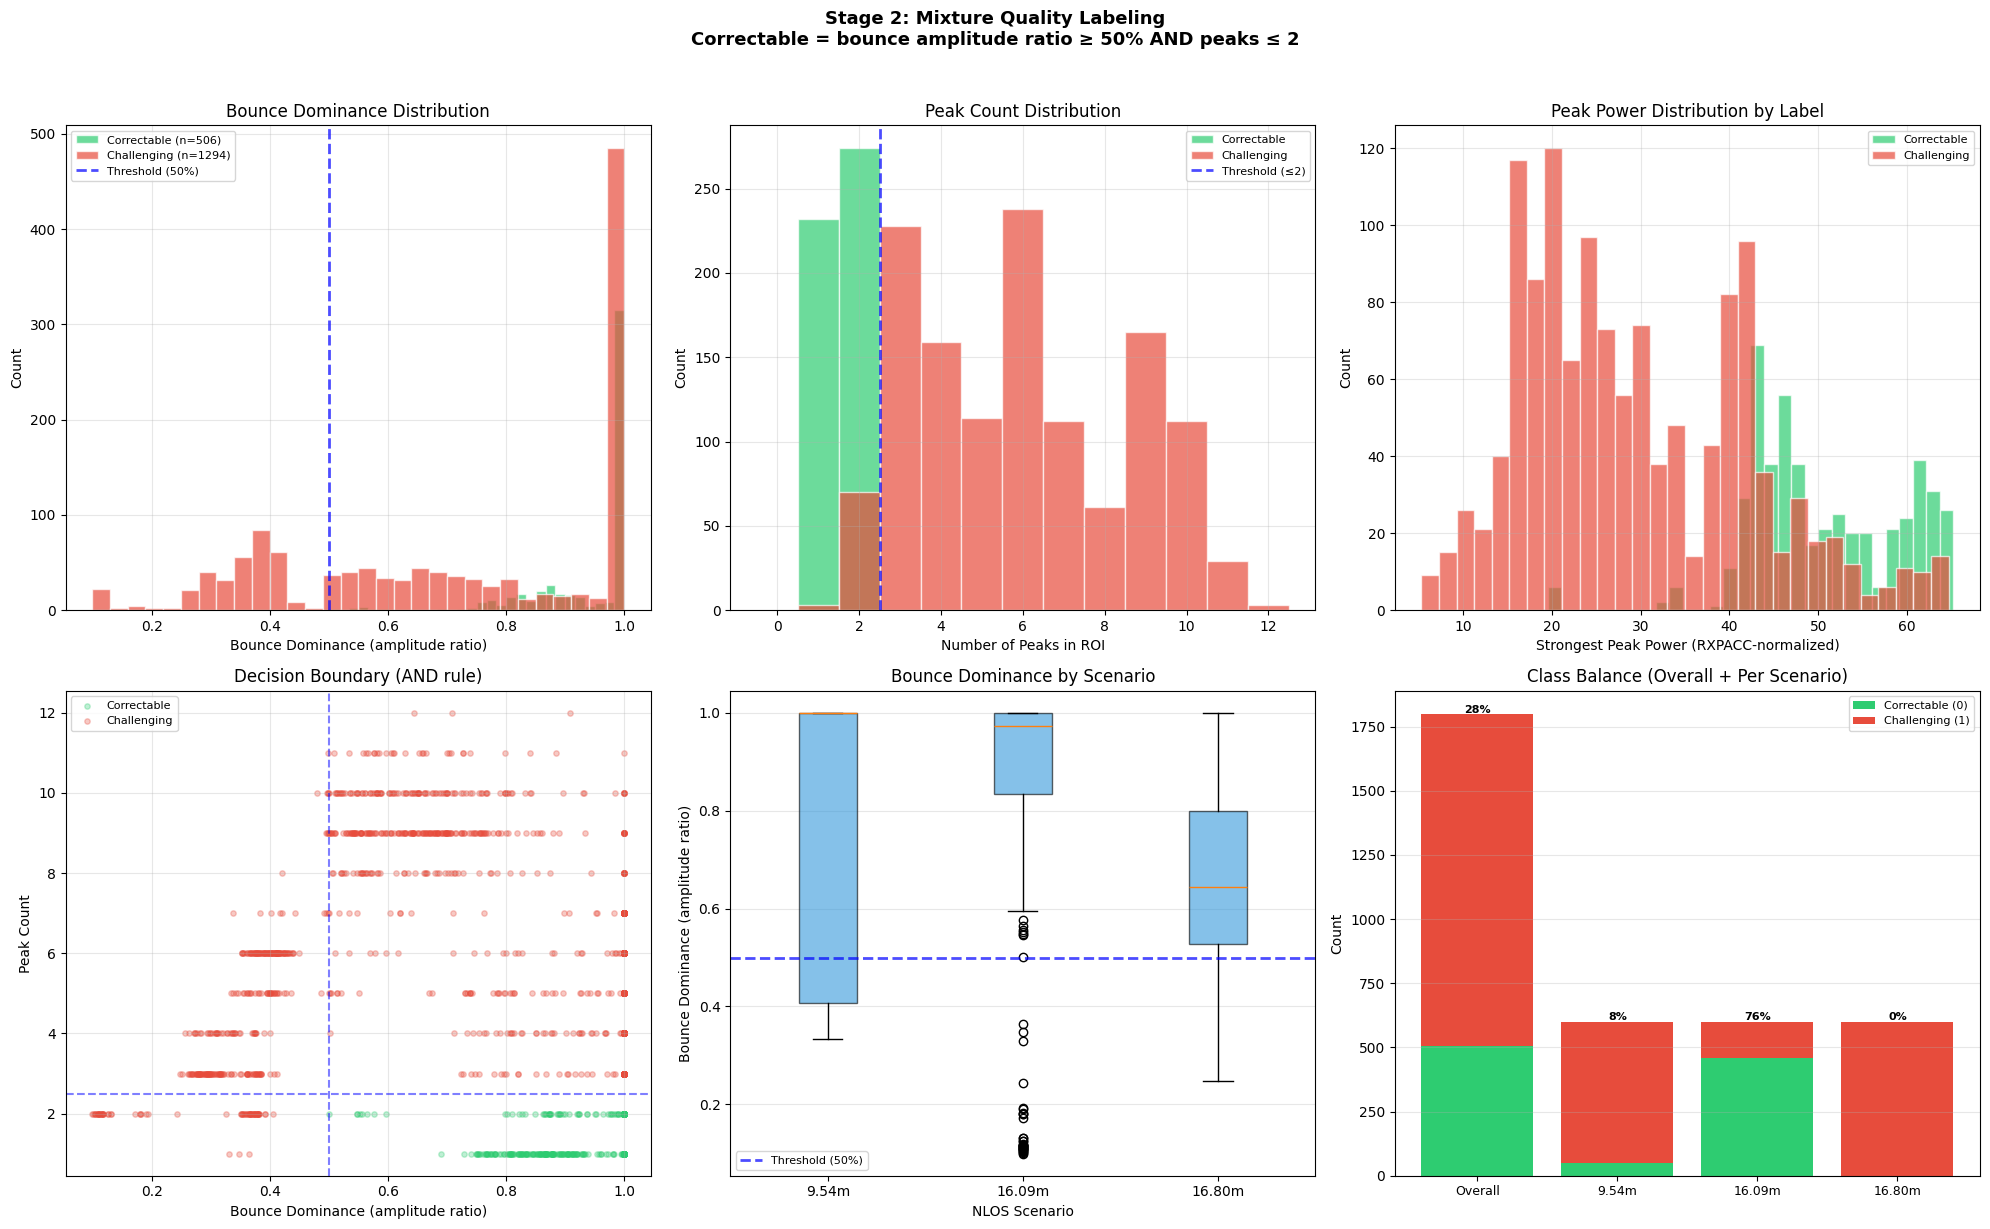

In [3]:
# ==========================================
# MIXTURE LABELING VISUALIZATION
# ==========================================
dom_thresh = CONFIG["dominance_threshold"]
peak_thresh = CONFIG["dominant_path_max_peaks"]
n_correctable = int(np.sum(quality_labels == 0))
n_challenging = int(np.sum(quality_labels == 1))

print(f"Mixture labeling (amplitude ratio >= {dom_thresh:.0%} AND peaks <= {peak_thresh}):")
print(f"  Correctable: {n_correctable} ({100*n_correctable/len(quality_labels):.1f}%)")
print(f"  Challenging: {n_challenging} ({100*n_challenging/len(quality_labels):.1f}%)")

fig, axs = plt.subplots(2, 3, figsize=(20, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

correctable_mask = quality_labels == 0
challenging_mask = quality_labels == 1

# ─── 1. Bounce dominance histogram ───
ax = axs[0, 0]
ax.hist(bounce_dominance[correctable_mask], bins=30, color='#2ecc71', alpha=0.7,
        label=f'Correctable (n={n_correctable})', edgecolor='white')
ax.hist(bounce_dominance[challenging_mask], bins=30, color='#e74c3c', alpha=0.7,
        label=f'Challenging (n={n_challenging})', edgecolor='white')
ax.axvline(dom_thresh, color='blue', ls='--', lw=2, alpha=0.7,
           label=f'Threshold ({dom_thresh:.0%})')
ax.set_xlabel('Bounce Dominance (amplitude ratio)')
ax.set_ylabel('Count')
ax.set_title('Bounce Dominance Distribution')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ─── 2. Peak count histogram ───
ax = axs[0, 1]
max_peaks = int(num_peaks.max())
bins_peaks = np.arange(-0.5, max_peaks + 1.5, 1)
ax.hist(num_peaks[correctable_mask], bins=bins_peaks, color='#2ecc71', alpha=0.7,
        label='Correctable', edgecolor='white')
ax.hist(num_peaks[challenging_mask], bins=bins_peaks, color='#e74c3c', alpha=0.7,
        label='Challenging', edgecolor='white')
ax.axvline(peak_thresh + 0.5, color='blue', ls='--', lw=2, alpha=0.7,
           label=f'Threshold (≤{peak_thresh})')
ax.set_xlabel('Number of Peaks in ROI')
ax.set_ylabel('Count')
ax.set_title('Peak Count Distribution')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ─── 3. Strongest peak power by label ───
ax = axs[0, 2]
ax.hist(strongest_peak_power[correctable_mask], bins=30, color='#2ecc71', alpha=0.7,
        label='Correctable', edgecolor='white')
ax.hist(strongest_peak_power[challenging_mask], bins=30, color='#e74c3c', alpha=0.7,
        label='Challenging', edgecolor='white')
ax.set_xlabel('Strongest Peak Power (RXPACC-normalized)')
ax.set_ylabel('Count')
ax.set_title('Peak Power Distribution by Label')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ─── 4. Scatter: dominance vs peak count ───
ax = axs[1, 0]
ax.scatter(bounce_dominance[correctable_mask], num_peaks[correctable_mask],
           c='#2ecc71', alpha=0.3, s=15, label='Correctable')
ax.scatter(bounce_dominance[challenging_mask], num_peaks[challenging_mask],
           c='#e74c3c', alpha=0.3, s=15, label='Challenging')
ax.axvline(dom_thresh, color='blue', ls='--', lw=1.5, alpha=0.5)
ax.axhline(peak_thresh + 0.5, color='blue', ls='--', lw=1.5, alpha=0.5)
ax.set_xlabel('Bounce Dominance (amplitude ratio)')
ax.set_ylabel('Peak Count')
ax.set_title('Decision Boundary (AND rule)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ─── 5. Per-scenario bounce dominance boxplot ───
ax = axs[1, 1]
source_files = nlos_df['Source_File'].values
groups = []
for sf in source_files:
    match = re.search(r'([\d.]+)m_nlos', str(sf))
    groups.append(match.group(1) + 'm' if match else 'unknown')
groups = np.array(groups)
unique_groups = sorted(set(groups), key=lambda x: float(x.replace('m', '')))

box_data = [bounce_dominance[groups == g] for g in unique_groups]
bp = ax.boxplot(box_data, labels=unique_groups, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
    patch.set_alpha(0.6)
ax.axhline(dom_thresh, color='blue', ls='--', lw=2, alpha=0.7,
           label=f'Threshold ({dom_thresh:.0%})')
ax.set_xlabel('NLOS Scenario')
ax.set_ylabel('Bounce Dominance (amplitude ratio)')
ax.set_title('Bounce Dominance by Scenario')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# ─── 6. Class balance: overall + per scenario ───
ax = axs[1, 2]
x_pos = np.arange(len(unique_groups) + 1)
labels_bar = ['Overall'] + unique_groups
correctable_counts = [n_correctable]
challenging_counts = [n_challenging]
for g in unique_groups:
    mask = groups == g
    correctable_counts.append(int(np.sum(quality_labels[mask] == 0)))
    challenging_counts.append(int(np.sum(quality_labels[mask] == 1)))

ax.bar(x_pos, correctable_counts, color='#2ecc71', label='Correctable (0)')
ax.bar(x_pos, challenging_counts, bottom=correctable_counts,
       color='#e74c3c', label='Challenging (1)')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_bar, fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Class Balance (Overall + Per Scenario)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

for i in range(len(x_pos)):
    total = correctable_counts[i] + challenging_counts[i]
    pct = 100 * correctable_counts[i] / total if total > 0 else 0
    ax.text(x_pos[i], total + 5, f'{pct:.0f}%', ha='center', fontsize=8, fontweight='bold')

plt.suptitle(f'Stage 2: Mixture Quality Labeling\n'
             f'Correctable = bounce amplitude ratio ≥ {dom_thresh:.0%} AND peaks ≤ {peak_thresh}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 3: BERT Encoder — Embedding Extraction

The Stage 1 **BERT_Classifier** processes raw CIR sequences through a Transformer Encoder with multi-head self-attention. We **freeze** the trained encoder and extract **64-dim BERT embeddings** (time-averaged Transformer hidden states) for each NLOS sample.

These embeddings are passed to Stage 2 RF for signal quality classification and Stage 3 for bounce distance prediction (d_bounce). The Transformer captures global dependencies across the CIR waveform via self-attention.

**Key**: No FP_AMPL conditioning — processes raw CIR only. The readout computes LayerNorm((1/T) Σ h(t)) — average pooling over the self-attended positions.

In [4]:
import torch
import torch.nn as nn


class BERT_Classifier(nn.Module):
    """
    Small Transformer Encoder for CIR classification — average pooling design.
    No CLS token — classifier sees time-averaged Transformer hidden states.
    No FP_AMPL conditioning — processes raw CIR only.
    """
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.2, max_seq_len=60):
        super().__init__()
        self.d_model = d_model

        # Input projection: scalar CIR value -> d_model
        self.input_proj = nn.Linear(input_size, d_model)

        # Learnable positional embeddings (60 CIR positions, no CLS)
        self.pos_embed = nn.Parameter(torch.randn(1, max_seq_len, d_model) * 0.02)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Layer norm on pooled output
        self.norm = nn.LayerNorm(d_model)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
            nn.Sigmoid()
        )

    def _encode(self, x_seq):
        """Shared encoder: CIR -> transformer hidden states (B, 60, d_model)."""
        x = self.input_proj(x_seq)
        x = x + self.pos_embed[:, :x.size(1), :]
        h_all = self.transformer(x)
        return h_all

    def forward(self, x_seq, return_dynamics=False):
        h_all = self._encode(x_seq)
        h_avg = self.norm(h_all.mean(dim=1))
        pred = self.classifier(h_avg)
        if return_dynamics:
            return pred, h_all
        return pred

    def embed(self, x_seq):
        """Return d_model-dim embedding for Stage 2/3 compatibility."""
        h_all = self._encode(x_seq)
        return self.norm(h_all.mean(dim=1))


print(f"BERT_Classifier defined: {sum(p.numel() for p in BERT_Classifier().parameters()):,} params")
print(f"  Embedding dim: 64 (d_model)")
print(f"  Pooling: LayerNorm(average-over-time) — time-averaged Transformer hidden states")
print(f"  FP_AMPL conditioning: NONE")

BERT_Classifier defined: 73,153 params
  Embedding dim: 64 (d_model)
  Pooling: LayerNorm(average-over-time) — time-averaged Transformer hidden states
  FP_AMPL conditioning: NONE


In [5]:
# ==========================================
# LOAD FROZEN STAGE 1 BERT ENCODER & EXTRACT EMBEDDINGS
# ==========================================
# Load Stage 1 BERT config
_saved = torch.load("stage1_bert_config.pt", map_location="cpu", weights_only=False)
STAGE1_CONFIG = _saved["config"]
print("STAGE1_CONFIG loaded from stage1_bert_config.pt")
print(STAGE1_CONFIG)

EMBEDDING_DIM = STAGE1_CONFIG['d_model']  # 64
EMBEDDING_NAMES = [f'BERT_h{i}' for i in range(EMBEDDING_DIM)]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def preprocess_cir_for_bert(sig, leading_edge):
    """Convert a single RXPACC-normalized CIR + leading edge to 60-sample window."""
    PRE = STAGE1_CONFIG['pre_crop']
    TOTAL = STAGE1_CONFIG['total_len']
    start = max(0, leading_edge - PRE)
    end = start + TOTAL
    if end > len(sig):
        end = len(sig)
        start = max(0, end - TOTAL)
    crop = sig[start:end]
    if len(crop) < TOTAL:
        crop = np.pad(crop, (0, TOTAL - len(crop)), mode='constant')
    local_min, local_max = np.min(crop), np.max(crop)
    rng = local_max - local_min
    crop = (crop - local_min) / rng if rng > 0 else np.zeros(TOTAL)
    return crop


# Load frozen Stage 1 BERT encoder
bert_encoder = BERT_Classifier(
    input_size=STAGE1_CONFIG['input_size'],
    d_model=STAGE1_CONFIG['d_model'],
    nhead=STAGE1_CONFIG['nhead'],
    num_layers=STAGE1_CONFIG['num_layers'],
    dim_feedforward=STAGE1_CONFIG['dim_feedforward'],
    dropout=STAGE1_CONFIG['dropout'],
    max_seq_len=STAGE1_CONFIG['total_len'],
).to(device)

checkpoint_path = 'stage1_bert_best.pt'
bert_encoder.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
bert_encoder.eval()
for param in bert_encoder.parameters():
    param.requires_grad = False

print(f"\nLoaded frozen Stage 1 BERT encoder from {checkpoint_path}")
print(f"  Architecture: BERT_Classifier (d_model={STAGE1_CONFIG['d_model']}, "
      f"nhead={STAGE1_CONFIG['nhead']}, num_layers={STAGE1_CONFIG['num_layers']})")
print(f"  Device: {device}")
print(f"  Parameters: {sum(p.numel() for p in bert_encoder.parameters()):,} (all frozen)")
print(f"  Embedding dim: {EMBEDDING_DIM} (LayerNorm(avg-pooled Transformer states))")
print(f"  FP_AMPL conditioning: NONE")

# Extract 64-dim BERT embeddings for all NLOS samples
print(f"\nExtracting {EMBEDDING_DIM}-dim embeddings for {len(nlos_df)} NLOS samples...")

cir_sequences = []
for i in range(len(raw_sigs)):
    crop = preprocess_cir_for_bert(raw_sigs[i], leading_edges[i])
    cir_sequences.append(crop)

cir_tensor = torch.tensor(
    np.array(cir_sequences).reshape(-1, STAGE1_CONFIG['total_len'], 1),
    dtype=torch.float32
).to(device)

all_embeddings = []
with torch.no_grad():
    for i in range(0, len(cir_tensor), 256):
        batch_cir = cir_tensor[i:i+256]
        emb = bert_encoder.embed(batch_cir)  # (batch, 64)
        all_embeddings.append(emb.cpu().numpy())

embeddings = np.vstack(all_embeddings)

print(f"  Embeddings shape: {embeddings.shape}")
print(f"  Feature names: {EMBEDDING_NAMES[:3]} ... {EMBEDDING_NAMES[-1]}")
print(f"  Embedding stats — mean: {embeddings.mean():.4f}, std: {embeddings.std():.4f}")
print(f"\nReady for Random Forest training on {EMBEDDING_DIM}-dim BERT embeddings.")

STAGE1_CONFIG loaded from stage1_bert_config.pt
{'pre_crop': 10, 'post_crop': 50, 'total_len': 60, 'search_start': 740, 'search_end': 810, 'd_model': 64, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'input_size': 1, 'dropout': 0.2, 'batch_size': 64, 'max_epochs': 40, 'lr': 0.001, 'weight_decay': 0.0001, 'warmup_epochs': 3, 'patience': 10, 'grad_clip': 1.0, 'val_ratio': 0.15, 'test_ratio': 0.15, 'seed': 42}

Loaded frozen Stage 1 BERT encoder from stage1_bert_best.pt
  Architecture: BERT_Classifier (d_model=64, nhead=4, num_layers=2)
  Device: cuda
  Parameters: 73,153 (all frozen)
  Embedding dim: 64 (LayerNorm(avg-pooled Transformer states))
  FP_AMPL conditioning: NONE

Extracting 64-dim embeddings for 1800 NLOS samples...
  Embeddings shape: (1800, 64)
  Feature names: ['BERT_h0', 'BERT_h1', 'BERT_h2'] ... BERT_h63
  Embedding stats — mean: -0.0026, std: 1.0751

Ready for Random Forest training on 64-dim BERT embeddings.


In [6]:
# Save seen embeddings for reference notebook reproducibility
np.save("stage2_seen_embeddings.npy", embeddings)
np.save("stage2_seen_labels.npy", quality_labels)
print(f"Saved seen embeddings: {embeddings.shape} -> stage2_seen_embeddings.npy")
print(f"Saved seen labels: {quality_labels.shape} -> stage2_seen_labels.npy")

Saved seen embeddings: (1800, 64) -> stage2_seen_embeddings.npy
Saved seen labels: (1800,) -> stage2_seen_labels.npy


---
## Section 4: CIR Waveform Examples

Compare **Correctable** (clean, bounce-dominated, few peaks) vs **Challenging** (dispersed energy or complex morphology) CIR waveforms.

Red vertical line marks the geometric bounce position (`bounce_path_idx`). Shaded red region shows the ±3 search window used for bounce dominance computation.

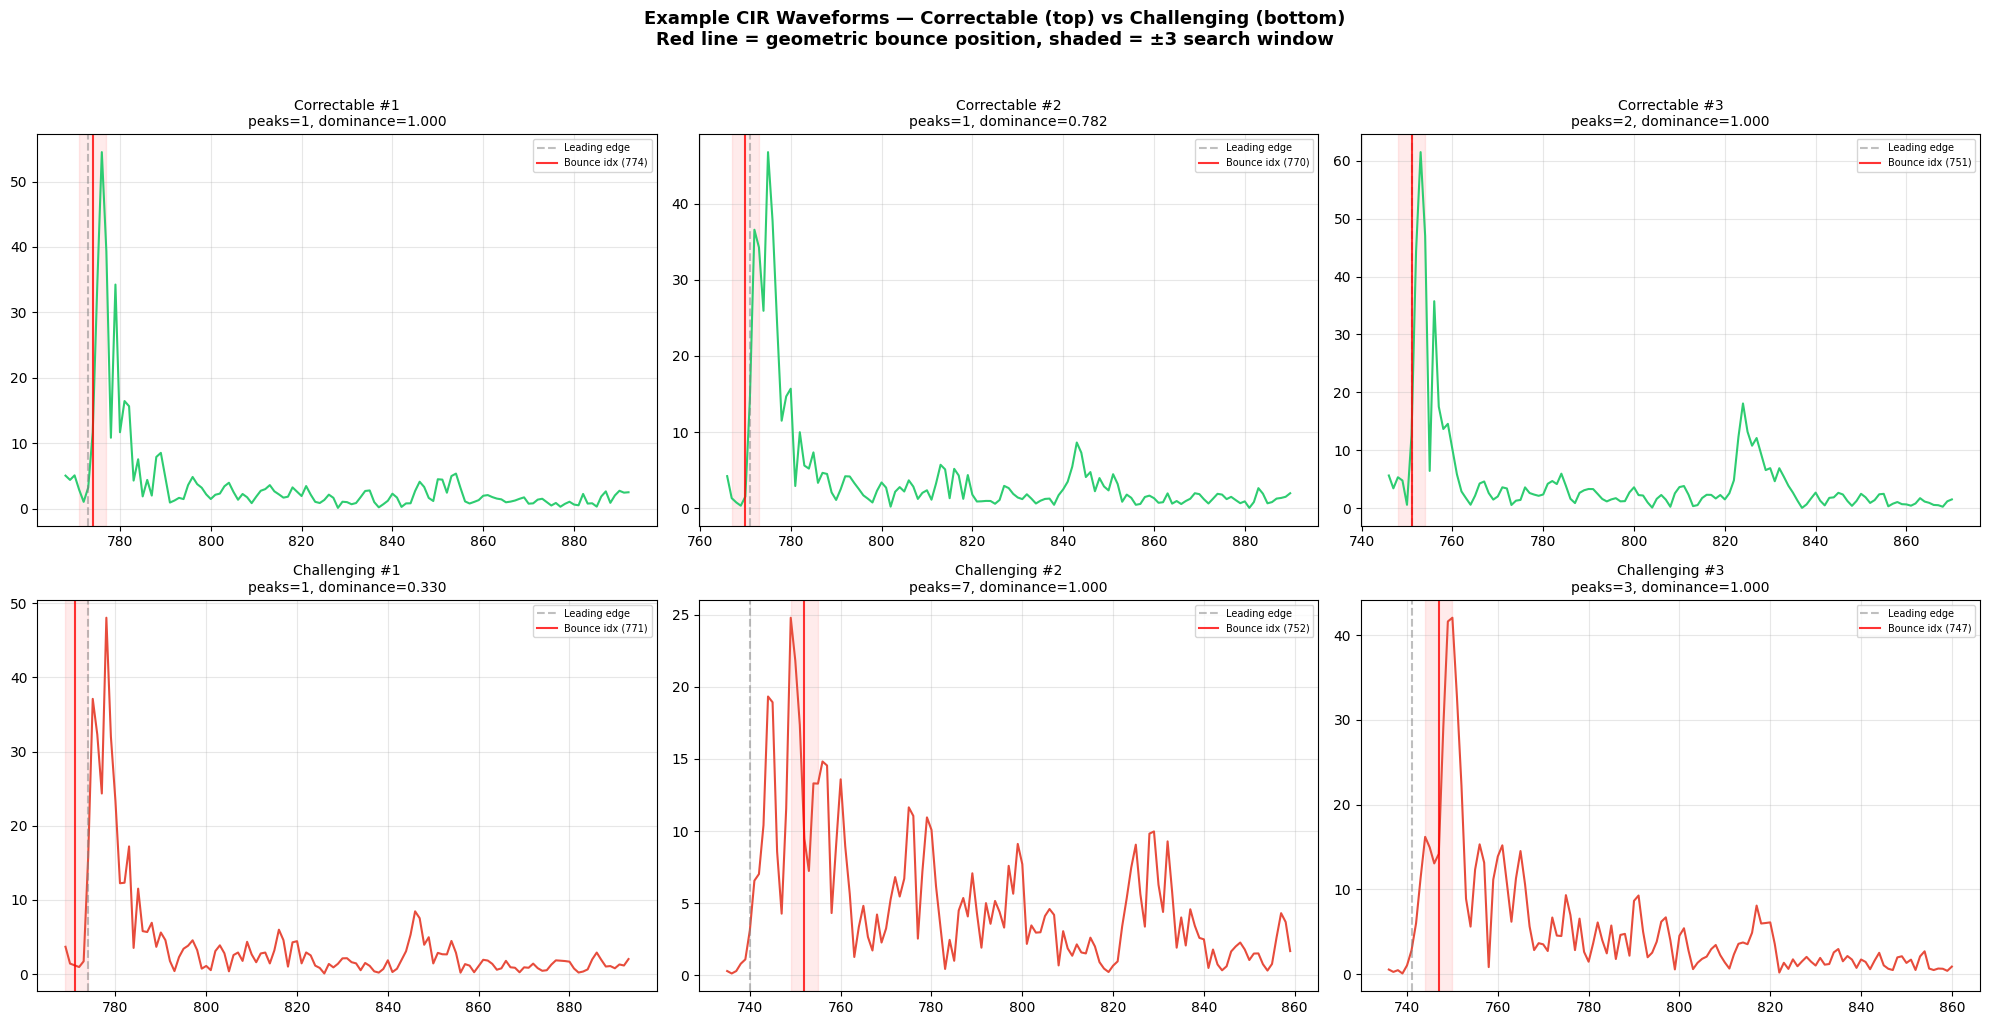

In [7]:
# ==========================================
# EXAMPLE CIR WAVEFORMS (Correctable vs Challenging)
# ==========================================
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
plt.subplots_adjust(hspace=0.45, wspace=0.3)

W = CONFIG['bounce_search_window']
correctable_idx = np.where(quality_labels == 0)[0]
challenging_idx = np.where(quality_labels == 1)[0]

# Show 3 correctable examples (spread across dataset for diversity)
for col in range(3):
    if col >= len(correctable_idx):
        axs[0, col].axis('off')
        continue
    step = max(1, len(correctable_idx) // 3)
    idx = correctable_idx[min(col * step, len(correctable_idx) - 1)]
    sig = raw_sigs[idx]
    le = leading_edges[idx]
    bpi = float(nlos_df.iloc[idx].get('bounce_path_idx', np.nan))
    bounce_idx = int(round(bpi)) if not np.isnan(bpi) else None

    roi_start = max(0, le - 5)
    roi_end = min(len(sig), le + 120)
    x_range = np.arange(roi_start, roi_end)

    ax = axs[0, col]
    ax.plot(x_range, sig[roi_start:roi_end], color='#2ecc71', lw=1.5)
    ax.axvline(le, color='gray', ls='--', alpha=0.5, label='Leading edge')
    if bounce_idx is not None:
        ax.axvline(bounce_idx, color='red', ls='-', lw=1.5, alpha=0.8,
                   label=f'Bounce idx ({bounce_idx})')
        ax.axvspan(max(roi_start, bounce_idx - W), min(roi_end, bounce_idx + W),
                   color='red', alpha=0.08)
    ax.set_title(f"Correctable #{col+1}\n"
                 f"peaks={num_peaks[idx]}, dominance={bounce_dominance[idx]:.3f}",
                 fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Show 3 challenging examples (spread across dataset)
for col in range(3):
    if col >= len(challenging_idx):
        axs[1, col].axis('off')
        continue
    step = max(1, len(challenging_idx) // 3)
    idx = challenging_idx[min(col * step, len(challenging_idx) - 1)]
    sig = raw_sigs[idx]
    le = leading_edges[idx]
    bpi = float(nlos_df.iloc[idx].get('bounce_path_idx', np.nan))
    bounce_idx = int(round(bpi)) if not np.isnan(bpi) else None

    roi_start = max(0, le - 5)
    roi_end = min(len(sig), le + 120)
    x_range = np.arange(roi_start, roi_end)

    ax = axs[1, col]
    ax.plot(x_range, sig[roi_start:roi_end], color='#e74c3c', lw=1.5)
    ax.axvline(le, color='gray', ls='--', alpha=0.5, label='Leading edge')
    if bounce_idx is not None:
        ax.axvline(bounce_idx, color='red', ls='-', lw=1.5, alpha=0.8,
                   label=f'Bounce idx ({bounce_idx})')
        ax.axvspan(max(roi_start, bounce_idx - W), min(roi_end, bounce_idx + W),
                   color='red', alpha=0.08)
    ax.set_title(f"Challenging #{col+1}\n"
                 f"peaks={num_peaks[idx]}, dominance={bounce_dominance[idx]:.3f}",
                 fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Example CIR Waveforms — Correctable (top) vs Challenging (bottom)\n"
             f"Red line = geometric bounce position, shaded = ±{W} search window",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 4b: Single-Bounce NLOS Physics — Annotated CIR

Each NLOS scenario is a **single-bounce** reflection: TX → wall/pillar → RX.

The CIR reveals two key positions:
- **`los_path_idx`** (blue dashed): Where the **direct path** would arrive if unobstructed (distance `d_direct`)
- **`bounce_path_idx`** (red solid): Where the **reflected path** actually arrives (distance `d_bounce`)

The gap between them is the **NLOS ranging bias** — the extra path length from the bounce.

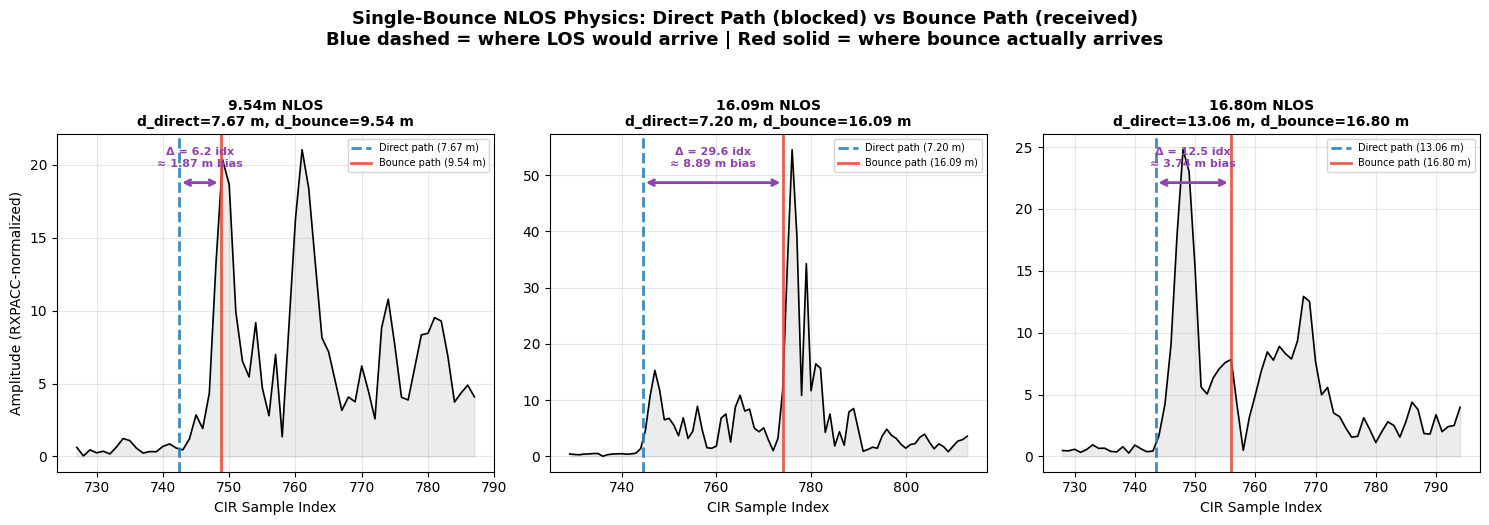


Scenario     d_direct (m)   d_bounce (m)   Bias (m)   Delay (idx) 
──────────────────────────────────────────────────────────────
9.54m        7.668          9.54           1.872      6.2         
16.09m       7.201          16.09          8.889      29.6        
16.80m       13.060         16.80          3.740      12.5        


In [8]:
# ==========================================
# SINGLE-BOUNCE NLOS PHYSICS — ANNOTATED CIR
# ==========================================
M_PER_INDEX = 0.3003  # ~1.0016 ns/sample × c

# Group by scenario
scenarios = {}
for i, row in nlos_df.iterrows():
    sf = str(row['Source_File'])
    match = re.search(r'([\d.]+)m_nlos', sf)
    if match:
        key = match.group(1) + 'm'
        local_idx = i - nlos_df.index[0]
        if key not in scenarios:
            scenarios[key] = local_idx

scenario_keys = sorted(scenarios.keys(), key=lambda k: float(k.replace('m', '')))
n_scenarios = len(scenario_keys)

fig, axs = plt.subplots(1, n_scenarios, figsize=(5 * n_scenarios, 5), sharey=False)
if n_scenarios == 1:
    axs = [axs]

for col, key in enumerate(scenario_keys):
    idx = scenarios[key]
    row = nlos_df.iloc[idx]
    sig = raw_sigs[idx]
    le = leading_edges[idx]

    los_idx = float(row['los_path_idx'])
    bounce_idx = float(row['bounce_path_idx'])
    d_direct = float(row['d_direct'])
    d_bounce = float(row['d_bounce'])
    bias_m = d_bounce - d_direct
    delay_samples = bounce_idx - los_idx

    view_start = max(0, int(los_idx) - 15)
    view_end = min(len(sig), int(bounce_idx) + 40)
    x_range = np.arange(view_start, view_end)

    ax = axs[col]
    ax.fill_between(x_range, sig[view_start:view_end], alpha=0.15, color='gray')
    ax.plot(x_range, sig[view_start:view_end], color='k', lw=1.2)

    ax.axvline(los_idx, color='#2980b9', ls='--', lw=2, alpha=0.9,
               label=f'Direct path ({d_direct:.2f} m)')
    ax.axvline(bounce_idx, color='#e74c3c', ls='-', lw=2, alpha=0.9,
               label=f'Bounce path ({d_bounce:.2f} m)')

    y_arrow = ax.get_ylim()[1] * 0.85
    ax.annotate('', xy=(bounce_idx, y_arrow), xytext=(los_idx, y_arrow),
                arrowprops=dict(arrowstyle='<->', color='#8e44ad', lw=2))
    mid_x = (los_idx + bounce_idx) / 2
    ax.text(mid_x, y_arrow * 1.05,
            f'Δ = {delay_samples:.1f} idx\n≈ {bias_m:.2f} m bias',
            ha='center', va='bottom', fontsize=8, fontweight='bold', color='#8e44ad')

    ax.set_title(f'{key} NLOS\n'
                 f'd_direct={d_direct:.2f} m, d_bounce={d_bounce:.2f} m',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('CIR Sample Index')
    if col == 0:
        ax.set_ylabel('Amplitude (RXPACC-normalized)')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle('Single-Bounce NLOS Physics: Direct Path (blocked) vs Bounce Path (received)\n'
             'Blue dashed = where LOS would arrive | Red solid = where bounce actually arrives',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Scenario':<12} {'d_direct (m)':<14} {'d_bounce (m)':<14} {'Bias (m)':<10} {'Delay (idx)':<12}")
print('─' * 62)
for key in scenario_keys:
    idx = scenarios[key]
    row = nlos_df.iloc[idx]
    d_dir = float(row['d_direct'])
    d_bnc = float(row['d_bounce'])
    los_i = float(row['los_path_idx'])
    bnc_i = float(row['bounce_path_idx'])
    print(f"{key:<12} {d_dir:<14.3f} {d_bnc:<14.2f} {d_bnc - d_dir:<10.3f} {bnc_i - los_i:<12.1f}")

---
## 5. Train & Evaluate — 70/30 Stratified Split

Train RF on 70% of NLOS samples (stratified), test on the remaining 30%. This evaluates in-distribution classification performance.

In [9]:
# ==========================================
# TRAIN & EVALUATE — 70/30 STRATIFIED SPLIT
# ==========================================
X_all = embeddings  # (N, 64)
y_all = quality_labels
FEATURE_DIM = EMBEDDING_DIM
FEATURE_NAMES = EMBEDDING_NAMES

# Extract scenario label for each NLOS sample (for per-scenario breakdown)
scenario_labels = np.array([
    re.search(r'([\d.]+)m_nlos', str(sf)).group(1) + 'm'
    if re.search(r'([\d.]+)m_nlos', str(sf)) else 'unknown'
    for sf in nlos_df['Source_File'].values
])
unique_scenarios = sorted(set(scenario_labels), key=lambda x: float(x.replace('m', '')))

print(f"Total NLOS samples: {len(y_all)}")
print(f"  Correctable: {int(np.sum(y_all == 0))}, Challenging: {int(np.sum(y_all == 1))}")
print(f"NLOS scenarios: {unique_scenarios}")
for sc in unique_scenarios:
    mask = scenario_labels == sc
    n_corr = int(np.sum(y_all[mask] == 0))
    n_chal = int(np.sum(y_all[mask] == 1))
    print(f"  {sc:>8s}: {mask.sum()} samples (Correctable={n_corr}, Challenging={n_chal})")

# 70/30 stratified split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, y_all, np.arange(len(y_all)),
    test_size=0.30,
    stratify=y_all,
    random_state=CONFIG["seed"]
)
scenario_test = scenario_labels[idx_test]

print(f"\nSplit: Train={len(X_train)} (70%), Test={len(X_test)} (30%)")
print(f"  Train — Correctable: {int(np.sum(y_train == 0))}, Challenging: {int(np.sum(y_train == 1))}")
print(f"  Test  — Correctable: {int(np.sum(y_test == 0))}, Challenging: {int(np.sum(y_test == 1))}")

# Train RF
rf_model = RandomForestClassifier(
    n_estimators=CONFIG["n_estimators"],
    max_depth=CONFIG["max_depth"],
    min_samples_split=CONFIG["min_samples_split"],
    min_samples_leaf=CONFIG["min_samples_leaf"],
    class_weight="balanced",
    random_state=CONFIG["seed"],
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
test_acc = (y_test == y_pred).mean()
proba = rf_model.predict_proba(X_test)
y_prob = proba[:, 1] if proba.shape[1] > 1 else proba[:, 0]
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob)
auc_test = auc(fpr_test, tpr_test)

print(f"\n{'=' * 60}")
print(f"70/30 SPLIT RESULTS — BERT {FEATURE_DIM}-dim → RF")
print(f"{'=' * 60}")
print(f"Overall Accuracy: {100*test_acc:.2f}%")
print(f"ROC AUC:          {auc_test:.4f}")
print()
print(classification_report(y_test, y_pred,
                             target_names=['Correctable', 'Challenging']))

# Per-scenario accuracy on test set
print("Per-scenario accuracy (test split):")
for sc in unique_scenarios:
    mask = scenario_test == sc
    if mask.sum() > 0:
        sc_acc = (y_test[mask] == y_pred[mask]).mean()
        print(f"  {sc:>8s} NLOS: {100*sc_acc:.1f}% (n={mask.sum()})")

Total NLOS samples: 1800
  Correctable: 506, Challenging: 1294
NLOS scenarios: [np.str_('9.54m'), np.str_('16.09m'), np.str_('16.80m')]
     9.54m: 600 samples (Correctable=49, Challenging=551)
    16.09m: 600 samples (Correctable=457, Challenging=143)
    16.80m: 600 samples (Correctable=0, Challenging=600)

Split: Train=1260 (70%), Test=540 (30%)
  Train — Correctable: 354, Challenging: 906
  Test  — Correctable: 152, Challenging: 388

70/30 SPLIT RESULTS — BERT 64-dim → RF
Overall Accuracy: 92.41%
ROC AUC:          0.9754

              precision    recall  f1-score   support

 Correctable       0.87      0.86      0.86       152
 Challenging       0.95      0.95      0.95       388

    accuracy                           0.92       540
   macro avg       0.91      0.91      0.91       540
weighted avg       0.92      0.92      0.92       540

Per-scenario accuracy (test split):
     9.54m NLOS: 90.1% (n=192)
    16.09m NLOS: 88.4% (n=190)
    16.80m NLOS: 100.0% (n=158)


---
## 6. Diagnostics — 70/30 Split

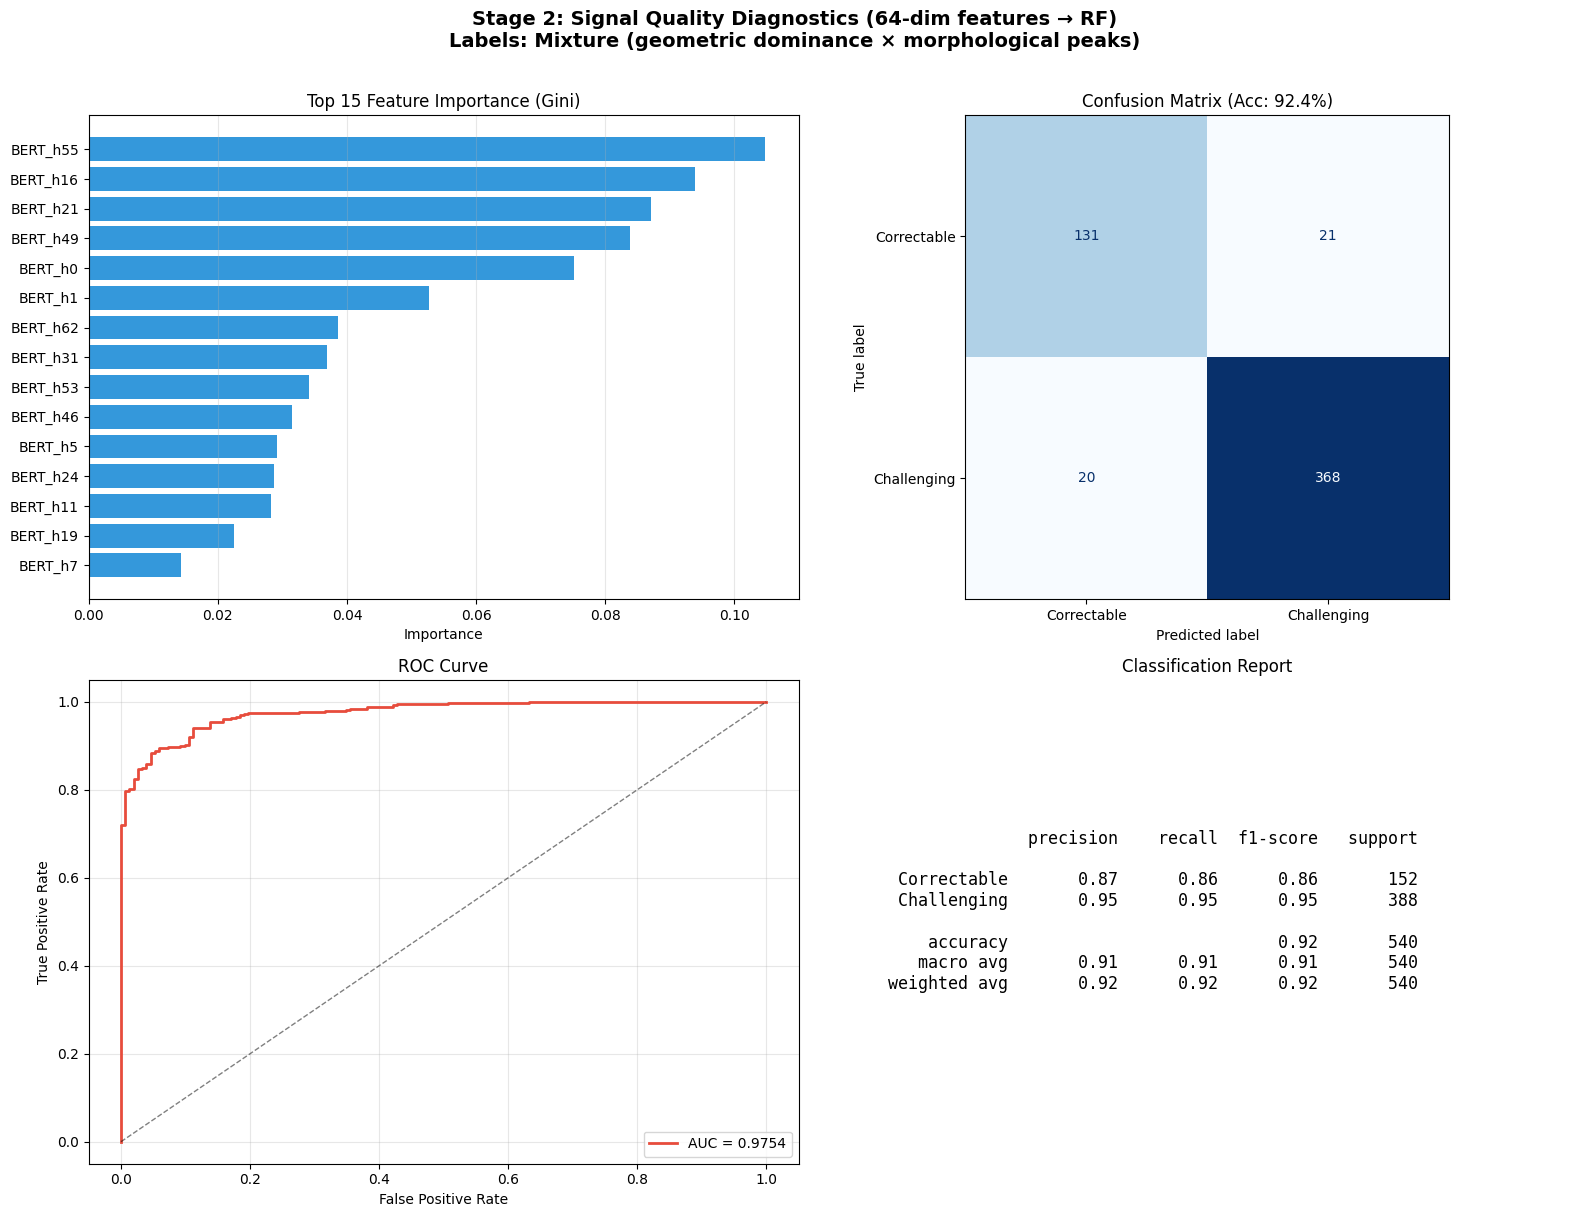


Top 15 Feature Importance (ranked):
  BERT_h55                  0.1047
  BERT_h16                  0.0939
  BERT_h21                  0.0871
  BERT_h49                  0.0838
  BERT_h0                   0.0752
  BERT_h1                   0.0526
  BERT_h62                  0.0386
  BERT_h31                  0.0370
  BERT_h53                  0.0342
  BERT_h46                  0.0315
  BERT_h5                   0.0291
  BERT_h24                  0.0286
  BERT_h11                  0.0283
  BERT_h19                  0.0224
  BERT_h7                   0.0144


In [10]:
# ==========================================
# DIAGNOSTICS
# ==========================================
y_pred_diag = rf_model.predict(X_test)

proba_diag = rf_model.predict_proba(X_test)
if proba_diag.shape[1] > 1:
    y_prob_diag = proba_diag[:, 1]
else:
    y_prob_diag = proba_diag[:, 0]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

# 1. Feature Importance (top 15 dims)
ax = axs[0, 0]
importances = rf_model.feature_importances_
top_k = min(15, len(importances))
sorted_idx = np.argsort(importances)[-top_k:]
ax.barh(np.array(FEATURE_NAMES)[sorted_idx], importances[sorted_idx], color='#3498db')
ax.set_title(f"Top {top_k} Feature Importance (Gini)")
ax.set_xlabel("Importance")
ax.grid(True, alpha=0.3, axis='x')

# 2. Confusion Matrix
ax = axs[0, 1]
cm = confusion_matrix(y_test, y_pred_diag)
disp = ConfusionMatrixDisplay(cm, display_labels=['Correctable', 'Challenging'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
acc = (y_test == y_pred_diag).mean()
ax.set_title(f"Confusion Matrix (Acc: {100*acc:.1f}%)")

# 3. ROC Curve
ax = axs[1, 0]
if len(np.unique(y_test)) > 1:
    fpr, tpr, _ = roc_curve(y_test, y_prob_diag)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_title("ROC Curve")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right')
else:
    ax.text(0.5, 0.5, 'Single class in test set', ha='center', va='center', fontsize=12)
    ax.set_title("ROC Curve (N/A)")
ax.grid(True, alpha=0.3)

# 4. Classification Report
ax = axs[1, 1]
report_text = classification_report(y_test, y_pred_diag,
                               target_names=['Correctable', 'Challenging'])
ax.text(0.05, 0.5, report_text, fontsize=12, fontfamily='monospace',
        verticalalignment='center', transform=ax.transAxes)
ax.set_title("Classification Report")
ax.axis('off')

plt.suptitle(f"Stage 2: Signal Quality Diagnostics ({FEATURE_DIM}-dim features → RF)\n"
             f"Labels: Mixture (geometric dominance × morphological peaks)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print top features
print(f"\nTop 15 Feature Importance (ranked):")
for feat, imp in sorted(zip(FEATURE_NAMES, importances), key=lambda x: -x[1])[:15]:
    print(f"  {feat:<25} {imp:.4f}")

---
## Section 6c: Model Comparison

Compare Random Forest against XGBoost, Logistic Regression, SVM, and Decision Tree on the same 70/30 split.

In [11]:
# ==========================================
# MODEL COMPARISON: RF vs XGBoost vs Logistic Regression vs SVM vs Decision Tree
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Models to compare (RF already trained above)
models = {
    "Random Forest": rf_model,
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=CONFIG["seed"], n_jobs=-1,
    ),
    "Logistic Reg.": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=CONFIG["seed"]))
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel='rbf', C=10, class_weight='balanced', probability=True, random_state=CONFIG["seed"]))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, class_weight='balanced', random_state=CONFIG["seed"]
    ),
}

# Train & evaluate each model
results = {}
model_predictions = {}

for name, model in models.items():
    if name == "Random Forest":
        y_pred_m = y_pred
        y_prob_m = y_prob
    else:
        model.fit(X_train, y_train)
        y_pred_m = model.predict(X_test)
        proba_m = model.predict_proba(X_test)
        y_prob_m = proba_m[:, 1] if proba_m.shape[1] > 1 else proba_m[:, 0]

    acc = (y_test == y_pred_m).mean()
    fpr_m, tpr_m, _ = roc_curve(y_test, y_prob_m)
    auc_m = auc(fpr_m, tpr_m)
    report = classification_report(y_test, y_pred_m,
                                   target_names=['Correctable', 'Challenging'],
                                   output_dict=True)

    results[name] = {
        "Accuracy": acc,
        "AUC": auc_m,
        "F1 (Corr.)": report['Correctable']['f1-score'],
        "F1 (Chal.)": report['Challenging']['f1-score'],
        "F1 (macro)": report['macro avg']['f1-score'],
    }
    model_predictions[name] = {"y_pred": y_pred_m, "y_prob": y_prob_m, "fpr": fpr_m, "tpr": tpr_m}

# Display results table
print(f"{'Model':<18} {'Acc':>8} {'AUC':>8} {'F1(Corr)':>10} {'F1(Chal)':>10} {'F1(macro)':>10}")
print("-" * 68)
for name, r in results.items():
    print(f"{name:<18} {100*r['Accuracy']:>7.2f}% {r['AUC']:>8.4f} {r['F1 (Corr.)']:>10.4f} {r['F1 (Chal.)']:>10.4f} {r['F1 (macro)']:>10.4f}")

c:\Users\preca\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:36:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model                   Acc      AUC   F1(Corr)   F1(Chal)  F1(macro)
--------------------------------------------------------------------
Random Forest        92.41%   0.9754     0.8647     0.9472     0.9060
XGBoost              92.22%   0.9796     0.8591     0.9463     0.9027
Logistic Reg.        92.04%   0.9712     0.8669     0.9432     0.9050
SVM (RBF)            92.22%   0.9686     0.8704     0.9444     0.9074
Decision Tree        90.37%   0.8883     0.8344     0.9321     0.8833


C:\Users\preca\AppData\Local\Temp\ipykernel_21452\1713262015.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)


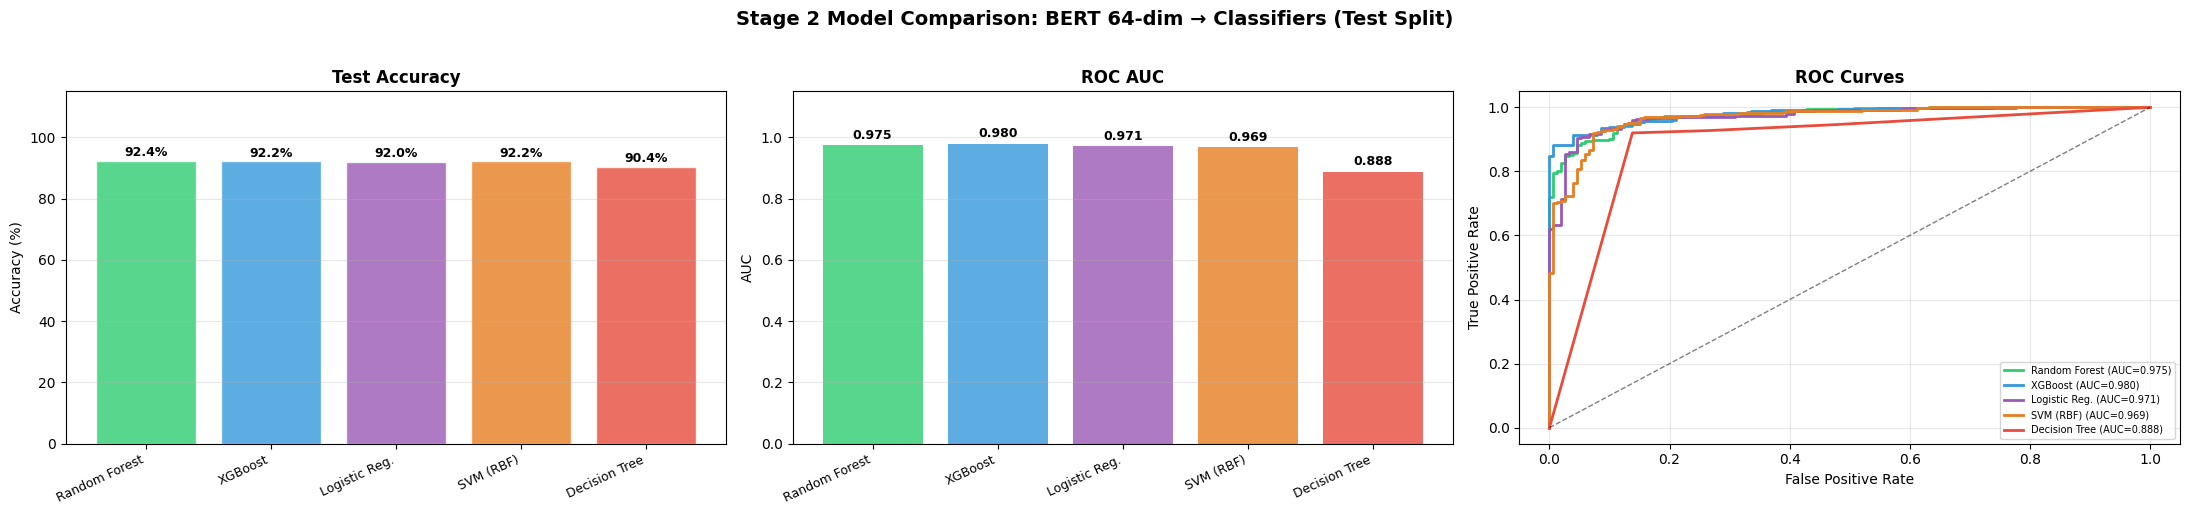

In [12]:
# ==========================================
# MODEL COMPARISON VISUALIZATION
# ==========================================
model_names = list(results.keys())
accs = [results[n]["Accuracy"] for n in model_names]
aucs = [results[n]["AUC"] for n in model_names]
f1_macros = [results[n]["F1 (macro)"] for n in model_names]

colors = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22', '#e74c3c']

fig, axs = plt.subplots(1, 3, figsize=(22, 5))
plt.subplots_adjust(wspace=0.35)

# 1. Accuracy bars
ax = axs[0]
x = np.arange(len(model_names))
bars = ax.bar(x, [100*v for v in accs], color=colors, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{100*val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Test Accuracy', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 115)

# 2. AUC bars
ax = axs[1]
bars = ax.bar(model_names, aucs, color=colors, alpha=0.8)
ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('AUC')
ax.set_title('ROC AUC', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.15)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. ROC Curves
ax = axs[2]
for idx, name in enumerate(model_names):
    fpr_m = model_predictions[name]["fpr"]
    tpr_m = model_predictions[name]["tpr"]
    auc_m = results[name]["AUC"]
    ax.plot(fpr_m, tpr_m, color=colors[idx], lw=2, label=f'{name} (AUC={auc_m:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=7)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Stage 2 Model Comparison: BERT {FEATURE_DIM}-dim \u2192 Classifiers (Test Split)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6b. Unseen Dataset Evaluation — All Models

Evaluate **all 5 models** (RF, XGBoost, Logistic Regression, SVM, Decision Tree) on a **completely separate dataset** (`unseen_dataset.csv`) containing 2 NLOS scenarios (8.91m, 12.79m) never seen during training. This tests out-of-distribution generalization.

Loading: ../dataset/channels/unseen_dataset.csv
  Total samples: 2400, NLOS samples: 1200

  Mixture labeling (amplitude ratio >= 50% AND peaks <= 2):
    ──────────────────────────────────────────────────
    Correctable (clean bounce):     406 (33.8%)
    Challenging (multipath/noisy):   794 (66.2%)
    ──────────────────────────────────────────────────
    Bounce dominance stats — mean: 0.851, median: 1.000
    Peak count stats — mean: 3.91, max: 10
    Strongest peak power stats — mean: 18.6895, min: 5.9535, max: 49.7966

Unseen NLOS samples: 1200
  Correctable: 406, Challenging: 794
  Unseen embeddings shape: (1200, 64)

UNSEEN DATASET: BERT 64-dim → All Models
Dataset: unseen_dataset.csv (1200 NLOS samples)

Model                   Acc      AUC   F1(Corr)   F1(Chal)  F1(macro)
--------------------------------------------------------------------
Random Forest        71.33%   0.8265     0.3653     0.8149     0.5901
XGBoost              69.67%   0.8285     0.3184     0.8049     0.56

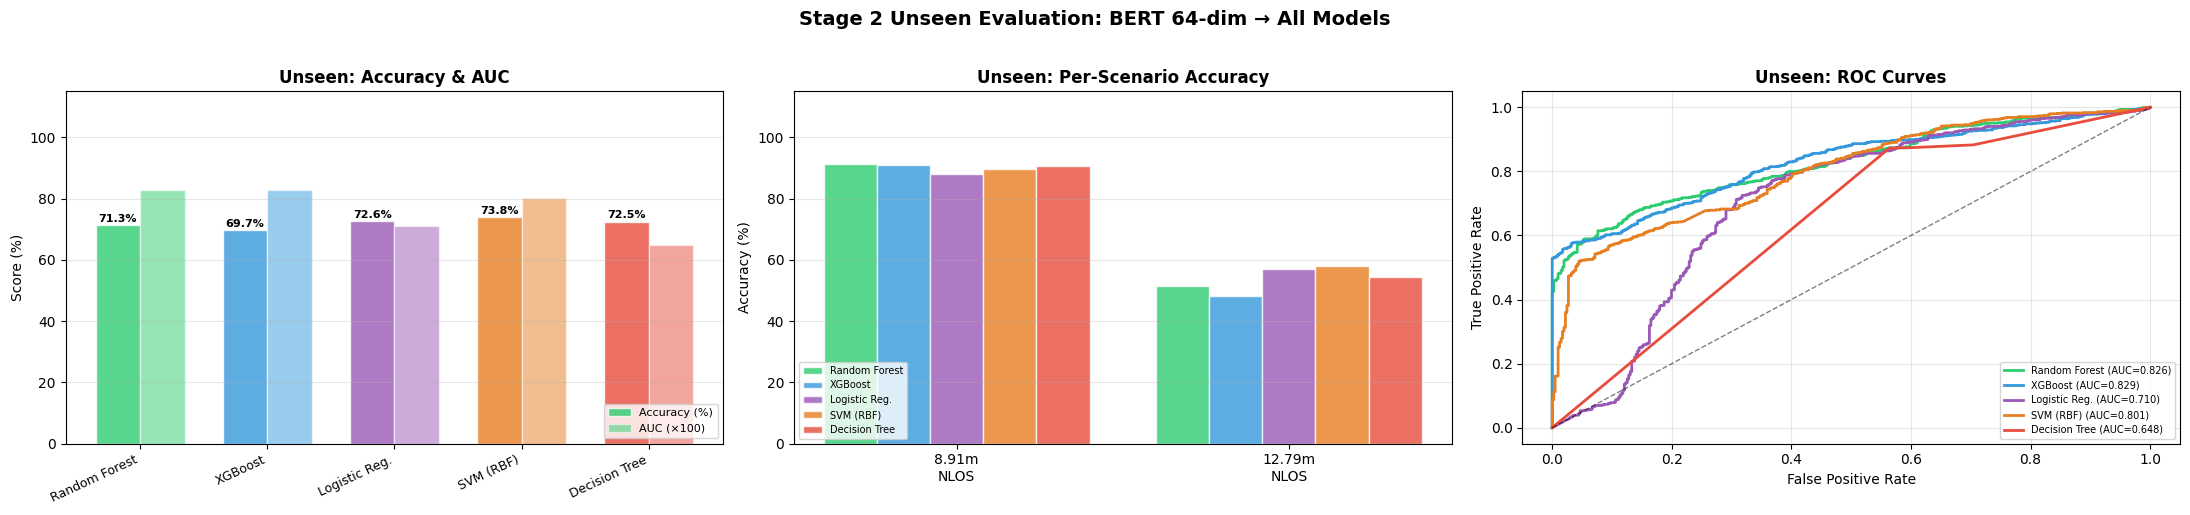

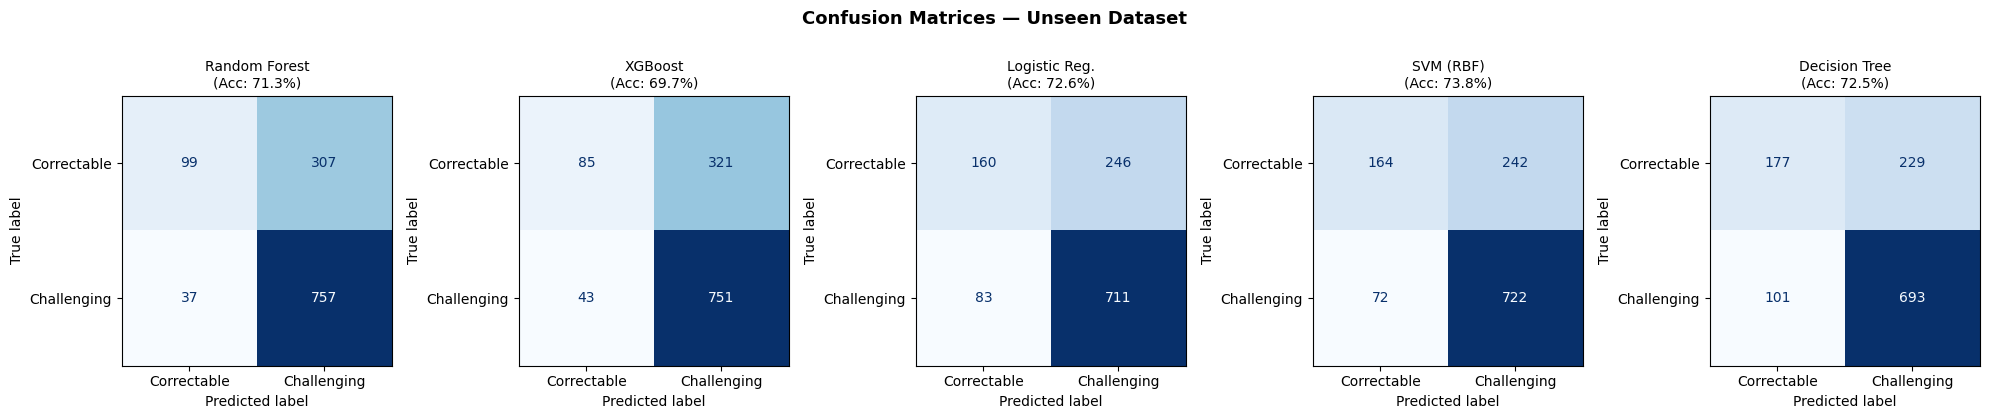


SUMMARY: Test Split vs Unseen Dataset

Model                Test Acc   Test AUC   Unseen Acc   Unseen AUC
-----------------------------------------------------------------
Random Forest          92.41%     0.9754       71.33%       0.8265
XGBoost                92.22%     0.9796       69.67%       0.8285
Logistic Reg.          92.04%     0.9712       72.58%       0.7102
SVM (RBF)              92.22%     0.9686       73.83%       0.8013
Decision Tree          90.37%     0.8883       72.50%       0.6476


In [13]:
# ==========================================
# UNSEEN DATASET EVALUATION — ALL MODELS
# ==========================================
unseen_filepath = "../dataset/channels/unseen_dataset.csv"

# Load and process unseen NLOS data
(unseen_raw_sigs, unseen_leading_edges, unseen_nlos_df,
 unseen_labels, unseen_num_peaks, unseen_bounce_dom,
 unseen_spp) = load_nlos_features(unseen_filepath)

print(f"\nUnseen NLOS samples: {len(unseen_labels)}")
print(f"  Correctable: {int(np.sum(unseen_labels==0))}, Challenging: {int(np.sum(unseen_labels==1))}")

# Extract BERT embeddings for unseen data
unseen_cir_sequences = []
for i in range(len(unseen_raw_sigs)):
    crop = preprocess_cir_for_bert(unseen_raw_sigs[i], unseen_leading_edges[i])
    unseen_cir_sequences.append(crop)

unseen_cir_tensor = torch.tensor(
    np.array(unseen_cir_sequences).reshape(-1, STAGE1_CONFIG['total_len'], 1),
    dtype=torch.float32
).to(device)

unseen_embeddings_list = []
with torch.no_grad():
    for i in range(0, len(unseen_cir_tensor), 256):
        batch_cir = unseen_cir_tensor[i:i+256]
        emb = bert_encoder.embed(batch_cir)
        unseen_embeddings_list.append(emb.cpu().numpy())

unseen_embeddings = np.vstack(unseen_embeddings_list)
print(f"  Unseen embeddings shape: {unseen_embeddings.shape}")

# ── Features & labels ──
X_unseen = unseen_embeddings
y_unseen = unseen_labels

# ── Per-scenario labels ──
unseen_scenarios = np.array([
    re.search(r'([\d.]+)m_nlos', str(sf)).group(1) + 'm'
    if re.search(r'([\d.]+)m_nlos', str(sf)) else 'unknown'
    for sf in unseen_nlos_df['Source_File'].values
])
unseen_unique_scenarios = sorted(set(unseen_scenarios), key=lambda x: float(x.replace('m', '')))

# ── Evaluate ALL models on unseen data ──
unseen_results = {}
unseen_predictions = {}

for name, model in models.items():
    y_pred_m = model.predict(X_unseen)
    proba_m = model.predict_proba(X_unseen)
    y_prob_m = proba_m[:, 1] if proba_m.shape[1] > 1 else proba_m[:, 0]

    acc_m = (y_unseen == y_pred_m).mean()
    fpr_m, tpr_m, _ = roc_curve(y_unseen, y_prob_m)
    auc_m = auc(fpr_m, tpr_m)
    report_m = classification_report(y_unseen, y_pred_m,
                                     target_names=['Correctable', 'Challenging'],
                                     output_dict=True)

    # Per-scenario accuracy
    per_scenario = {}
    for sc in unseen_unique_scenarios:
        mask = unseen_scenarios == sc
        if mask.sum() > 0:
            per_scenario[sc] = (y_unseen[mask] == y_pred_m[mask]).mean()

    unseen_results[name] = {
        "Accuracy": acc_m,
        "AUC": auc_m,
        "F1 (Corr.)": report_m['Correctable']['f1-score'],
        "F1 (Chal.)": report_m['Challenging']['f1-score'],
        "F1 (macro)": report_m['macro avg']['f1-score'],
        "Per-scenario": per_scenario,
    }
    unseen_predictions[name] = {"y_pred": y_pred_m, "y_prob": y_prob_m, "fpr": fpr_m, "tpr": tpr_m}

# ── Keep RF results easily accessible for summary cell ──
y_pred_unseen = unseen_predictions["Random Forest"]["y_pred"]
acc_unseen = unseen_results["Random Forest"]["Accuracy"]
auc_u = unseen_results["Random Forest"]["AUC"]

# ── Print comparison table ──
print("\n" + "=" * 80)
print(f"UNSEEN DATASET: BERT {FEATURE_DIM}-dim \u2192 All Models")
print(f"Dataset: unseen_dataset.csv ({len(y_unseen)} NLOS samples)")
print("=" * 80)
print(f"\n{'Model':<18} {'Acc':>8} {'AUC':>8} {'F1(Corr)':>10} {'F1(Chal)':>10} {'F1(macro)':>10}")
print("-" * 68)
for name, r in unseen_results.items():
    print(f"{name:<18} {100*r['Accuracy']:>7.2f}% {r['AUC']:>8.4f} {r['F1 (Corr.)']:>10.4f} {r['F1 (Chal.)']:>10.4f} {r['F1 (macro)']:>10.4f}")

# ── Per-scenario breakdown ──
print(f"\nPer-scenario accuracy (unseen):")
header = f"  {'Scenario':<12}" + "".join(f"{name:>16}" for name in unseen_results)
print(header)
print("  " + "-" * (12 + 16 * len(unseen_results)))
for sc in unseen_unique_scenarios:
    row = f"  {sc + ' NLOS':<12}"
    for name, r in unseen_results.items():
        sc_acc = r["Per-scenario"].get(sc, 0)
        row += f"{100*sc_acc:>15.1f}%"
    print(row)

# ── VISUALIZATION ──
model_names_u = list(unseen_results.keys())
n_models = len(model_names_u)
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22', '#e74c3c']

fig, axs = plt.subplots(1, 3, figsize=(22, 5))
plt.subplots_adjust(wspace=0.35)

# Plot 1: Accuracy & AUC comparison
ax = axs[0]
accs_u = [unseen_results[n]["Accuracy"] for n in model_names_u]
aucs_u = [unseen_results[n]["AUC"] for n in model_names_u]
x = np.arange(n_models)
w = 0.35
bars1 = ax.bar(x - w/2, [100*v for v in accs_u], w, label='Accuracy (%)', color=colors, alpha=0.8, edgecolor='white')
bars2 = ax.bar(x + w/2, [100*v for v in aucs_u], w, label='AUC (\u00d7100)', color=colors, alpha=0.5, edgecolor='white')
for bar, val in zip(bars1, accs_u):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{100*val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names_u, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_title('Unseen: Accuracy & AUC', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 115)

# Plot 2: Per-scenario accuracy (grouped bar)
ax = axs[1]
n_sc = len(unseen_unique_scenarios)
x_sc = np.arange(n_sc)
bar_width = 0.8 / n_models
for idx, name in enumerate(model_names_u):
    sc_accs = [unseen_results[name]["Per-scenario"].get(sc, 0) for sc in unseen_unique_scenarios]
    offset = (idx - n_models/2 + 0.5) * bar_width
    bars = ax.bar(x_sc + offset, [100*v for v in sc_accs], bar_width,
                  label=name, color=colors[idx], alpha=0.8, edgecolor='white')
ax.set_xticks(x_sc)
ax.set_xticklabels([f'{s}\nNLOS' for s in unseen_unique_scenarios], fontsize=10)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Unseen: Per-Scenario Accuracy', fontsize=12, fontweight='bold')
ax.legend(fontsize=7, loc='lower left')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 115)

# Plot 3: ROC Curves (all models)
ax = axs[2]
for idx, name in enumerate(model_names_u):
    fpr_m = unseen_predictions[name]["fpr"]
    tpr_m = unseen_predictions[name]["tpr"]
    auc_m = unseen_results[name]["AUC"]
    ax.plot(fpr_m, tpr_m, color=colors[idx], lw=2, label=f'{name} (AUC={auc_m:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Unseen: ROC Curves', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=7)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Stage 2 Unseen Evaluation: BERT {FEATURE_DIM}-dim \u2192 All Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Confusion matrices (all models) ──
fig, axs_cm = plt.subplots(1, n_models, figsize=(4*n_models, 4))
for idx, name in enumerate(model_names_u):
    ax = axs_cm[idx]
    cm_m = confusion_matrix(y_unseen, unseen_predictions[name]["y_pred"])
    disp_m = ConfusionMatrixDisplay(cm_m, display_labels=['Correctable', 'Challenging'])
    disp_m.plot(ax=ax, cmap='Blues', colorbar=False)
    acc_m = unseen_results[name]["Accuracy"]
    ax.set_title(f"{name}\n(Acc: {100*acc_m:.1f}%)", fontsize=10)
plt.suptitle(f'Confusion Matrices \u2014 Unseen Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table: Test vs Unseen ──
print("\n" + "=" * 80)
print("SUMMARY: Test Split vs Unseen Dataset")
print("=" * 80)
print(f"\n{'Model':<18} {'Test Acc':>10} {'Test AUC':>10} {'Unseen Acc':>12} {'Unseen AUC':>12}")
print("-" * 65)
for name in model_names_u:
    t_acc = results[name]["Accuracy"]
    t_auc = results[name]["AUC"]
    u_acc = unseen_results[name]["Accuracy"]
    u_auc = unseen_results[name]["AUC"]
    print(f"{name:<18} {100*t_acc:>9.2f}% {t_auc:>10.4f} {100*u_acc:>11.2f}% {u_auc:>12.4f}")

In [14]:
# Save unseen embeddings for reference notebook reproducibility
np.save("stage2_unseen_embeddings.npy", unseen_embeddings)
np.save("stage2_unseen_labels.npy", unseen_labels)
print(f"Saved unseen embeddings: {unseen_embeddings.shape} -> stage2_unseen_embeddings.npy")
print(f"Saved unseen labels: {unseen_labels.shape} -> stage2_unseen_labels.npy")

Saved unseen embeddings: (1200, 64) -> stage2_unseen_embeddings.npy
Saved unseen labels: (1200,) -> stage2_unseen_labels.npy


---
## Section 7: Save Artifacts

In [ ]:
# ==========================================
# SAVE ARTIFACTS
# ==========================================
joblib.dump(rf_model, "stage2_bounce_rf.joblib")
print("Saved: stage2_bounce_rf.joblib")

joblib.dump({
    "config": CONFIG,
    "embedding_dim": EMBEDDING_DIM,
    "embedding_names": EMBEDDING_NAMES,
    "feature_dim": FEATURE_DIM,
    "feature_names": FEATURE_NAMES,
    "stage1_config": STAGE1_CONFIG,
    "encoder_class": "BERT_Classifier",
    "fp_conditioning": False,
    "label_strategy": "mixture_geometric_morphological",
    "dominance_type": "amplitude_ratio",
    "dominance_threshold": CONFIG["dominance_threshold"],
    "bounce_search_window": CONFIG["bounce_search_window"],
    "dominant_path_max_peaks": CONFIG["dominant_path_max_peaks"],
    "note": f"Mixture labels: Correctable if bounce amplitude ratio >= {CONFIG['dominance_threshold']:.0%} "
            f"AND num_peaks <= {CONFIG['dominant_path_max_peaks']}. "
            f"Dominance = bounce_peak_amp / strongest_peak_amp (not energy ratio). "
            f"Model input is {FEATURE_DIM}-dim BERT embeddings. "
            f"RF predicts signal quality from embeddings alone.",
}, "stage2_config.joblib")
print("Saved: stage2_config.joblib")

print(f"\nDependency: stage1_bert_best.pt (frozen BERT_Classifier encoder)")
print(f"Feature dim: {FEATURE_DIM} (BERT embeddings only)")
print(f"Artifacts ready for Stage 3 pipeline (d_bounce prediction).")

In [ ]:
print("=" * 60)
print("Stage 2 — Summary")
print("=" * 60)
print(f"Model artifact: stage2_bounce_rf.joblib")
print(f"Config artifact: stage2_config.joblib")
print(f"Encoder dependency: stage1_bert_best.pt (frozen BERT_Classifier)")
print()
print(f"Architecture: Frozen BERT_Classifier encoder → {FEATURE_DIM}-dim embeddings → RF classifier")
print(f"  BERT embeddings: {EMBEDDING_DIM}-dim (LayerNorm(avg-pooled Transformer states))")
print()
print(f"Results:")
print(f"  70/30 split (test): Acc={100*test_acc:.2f}%, AUC={auc_test:.4f}")
print(f"  Unseen dataset:     Acc={100*acc_unseen:.2f}%, AUC={auc_u:.4f}")
print()
print(f"Labels: MIXTURE (geometric + morphological)")
print(f"  Criterion 1: bounce dominance >= {CONFIG['dominance_threshold']:.0%}")
print(f"  Criterion 2: num_peaks <= {CONFIG['dominant_path_max_peaks']}")
print(f"  Correctable (0): BOTH conditions met")
print(f"  Challenging (1): either condition violated")
print()
print("Pipeline: Stage 1 (BERT) → Stage 2 (BERT embeddings → RF → signal quality) → Stage 3 (d_bounce prediction)")